# CSE457 - LAB 2: ĐẶC TRƯNG TIẾNG NÓI VÀ NHẬN DẠNG BẰNG DTW
Notebook hoàn chỉnh theo thứ tự A → G của đề Lab.

> **Dữ liệu:** 5 từ `không, một, hai, ba, bốn`, mỗi từ 5 file. 3 file đầu train/template, 2 file cuối test. Dataset đi kèm là giọng tổng hợp tiếng Việt để project chạy ngay; nếu yêu cầu dữ liệu cá nhân, thay bằng bản ghi của bạn.

In [ ]:
from pathlib import Path
import sys, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ROOT=Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from lab2_pipeline import *
DATA=ROOT/'dataset'
print('FS=',FS,'WIN=',WIN,'HOP=',HOP,'N_MELS=',N_MELS,'N_MFCC=',N_MFCC)

FS= 16000 WIN= 400 HOP= 160 N_MELS= 24 N_MFCC= 13


## A. Dữ liệu và kiểm tra chất lượng

In [ ]:
meta=pd.read_csv(ROOT/'dataset_metadata.csv')
display(meta)
print(meta.groupby(['label_ascii','split']).size())

,file,label_ascii,label_vi,sample_rate,channels,subtype,duration_s,silence_pre_s,silence_post_s,tts_speed,tts_pitch,split
0,dataset/khong/khong_01.wav,khong,không,16000,1,PCM_16,0.861,0.30,0.32,135,42,train
1,dataset/khong/khong_02.wav,khong,không,16000,1,PCM_16,0.848,0.24,0.38,148,48,train
2,dataset/khong/khong_03.wav,khong,không,16000,1,PCM_16,0.815,0.36,0.25,160,53,train
3,dataset/khong/khong_04.wav,khong,không,16000,1,PCM_16,0.814,0.28,0.34,172,58,test
4,dataset/khong/khong_05.wav,khong,không,16000,1,PCM_16,0.929,0.40,0.30,145,64,test
5,dataset/mot/mot_01.wav,mot,một,16000,1,PCM_16,0.928,0.30,0.32,135,42,train
6,dataset/mot/mot_02.wav,mot,một,16000,1,PCM_16,0.911,0.24,0.38,148,48,train
7,dataset/mot/mot_03.wav,mot,một,16000,1,PCM_16,0.877,0.36,0.25,160,53,train
8,dataset/mot/mot_04.wav,mot,một,16000,1,PCM_16,0.873,0.28,0.34,172,58,test
9,dataset/mot/mot_05.wav,mot,một,16000,1,PCM_16,0.996,0.40,0.30,145,64,test


label_ascii  split
ba           test     2
             train    3
bon          test     2
             train    3
hai          test     2
             train    3
khong        test     2
             train    3
mot          test     2
             train    3
dtype: int64


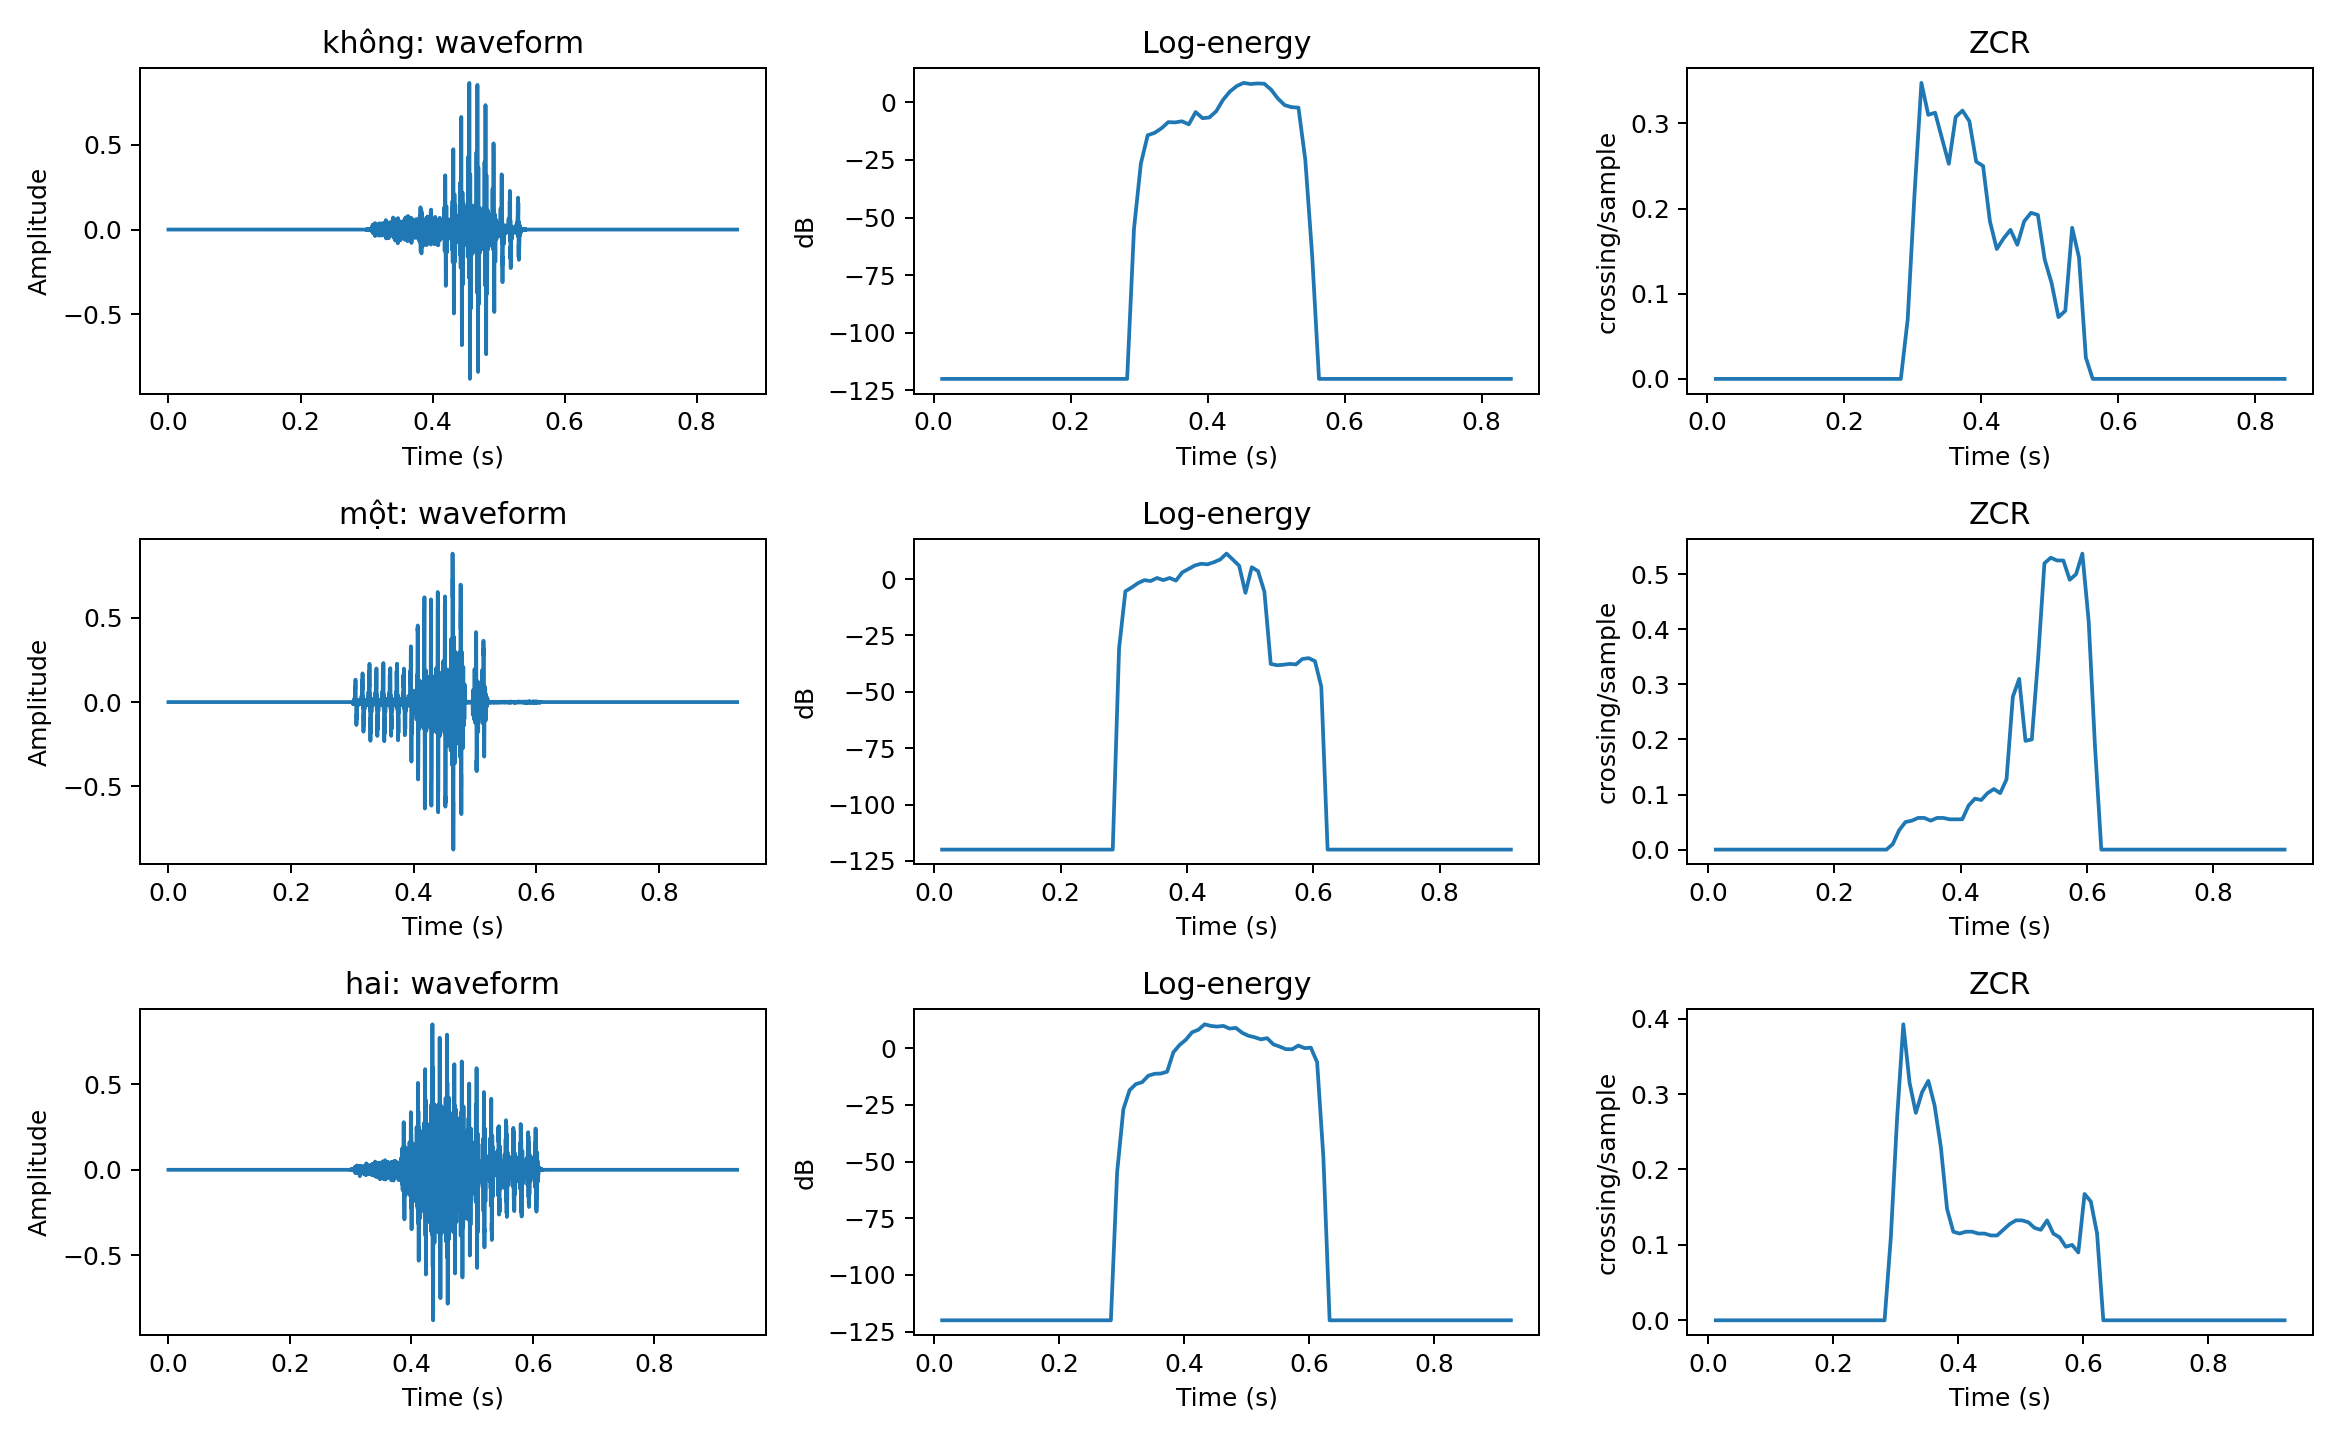

In [ ]:
from IPython.display import display, Image
display(Image(filename=str(ROOT/'figures'/'waveform_energy_zcr_3words.png')))

## B. Energy, magnitude, RMS và ZCR
Silence có energy thấp; voiced thường energy cao/ZCR thấp; unvoiced có thể ZCR cao. Các đại lượng được tự tính trên frame 25 ms, hop 10 ms.

In [ ]:
p=DATA/'khong'/'khong_01.wav'
y=load_audio(p)
t,E,Mag,R,Z,L=short_time_features(y)
print('frames=',len(t),'energy range=',(E.min(),E.max()),'ZCR range=',(Z.min(),Z.max()))

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


frames= 84 energy range= (np.float64(0.0), np.float64(6.90176001131428)) ZCR range= (np.float64(0.0), np.float64(0.3475))


## C. Endpoint detection

,file,label,before_s,after_s,start_s,end_s,noise_db,energy_threshold_db
0,khong_01.wav,khong,0.861313,0.385,0.23,0.615,-120.0,-110.0
1,khong_02.wav,khong,0.847562,0.365,0.17,0.535,-120.0,-110.0
2,khong_03.wav,khong,0.814813,0.345,0.29,0.635,-120.0,-110.0
3,khong_04.wav,khong,0.813813,0.335,0.21,0.545,-120.0,-110.0
4,khong_05.wav,khong,0.929250,0.365,0.33,0.695,-120.0,-110.0
5,mot_01.wav,mot,0.927562,0.445,0.23,0.675,-120.0,-110.0
6,mot_02.wav,mot,0.911312,0.435,0.17,0.605,-120.0,-110.0
7,mot_03.wav,mot,0.876750,0.405,0.29,0.695,-120.0,-110.0
8,mot_04.wav,mot,0.873313,0.395,0.21,0.605,-120.0,-110.0
9,mot_05.wav,mot,0.995687,0.435,0.33,0.765,-120.0,-110.0


Mean duration before: 0.8830225 after: 0.38780000000000003


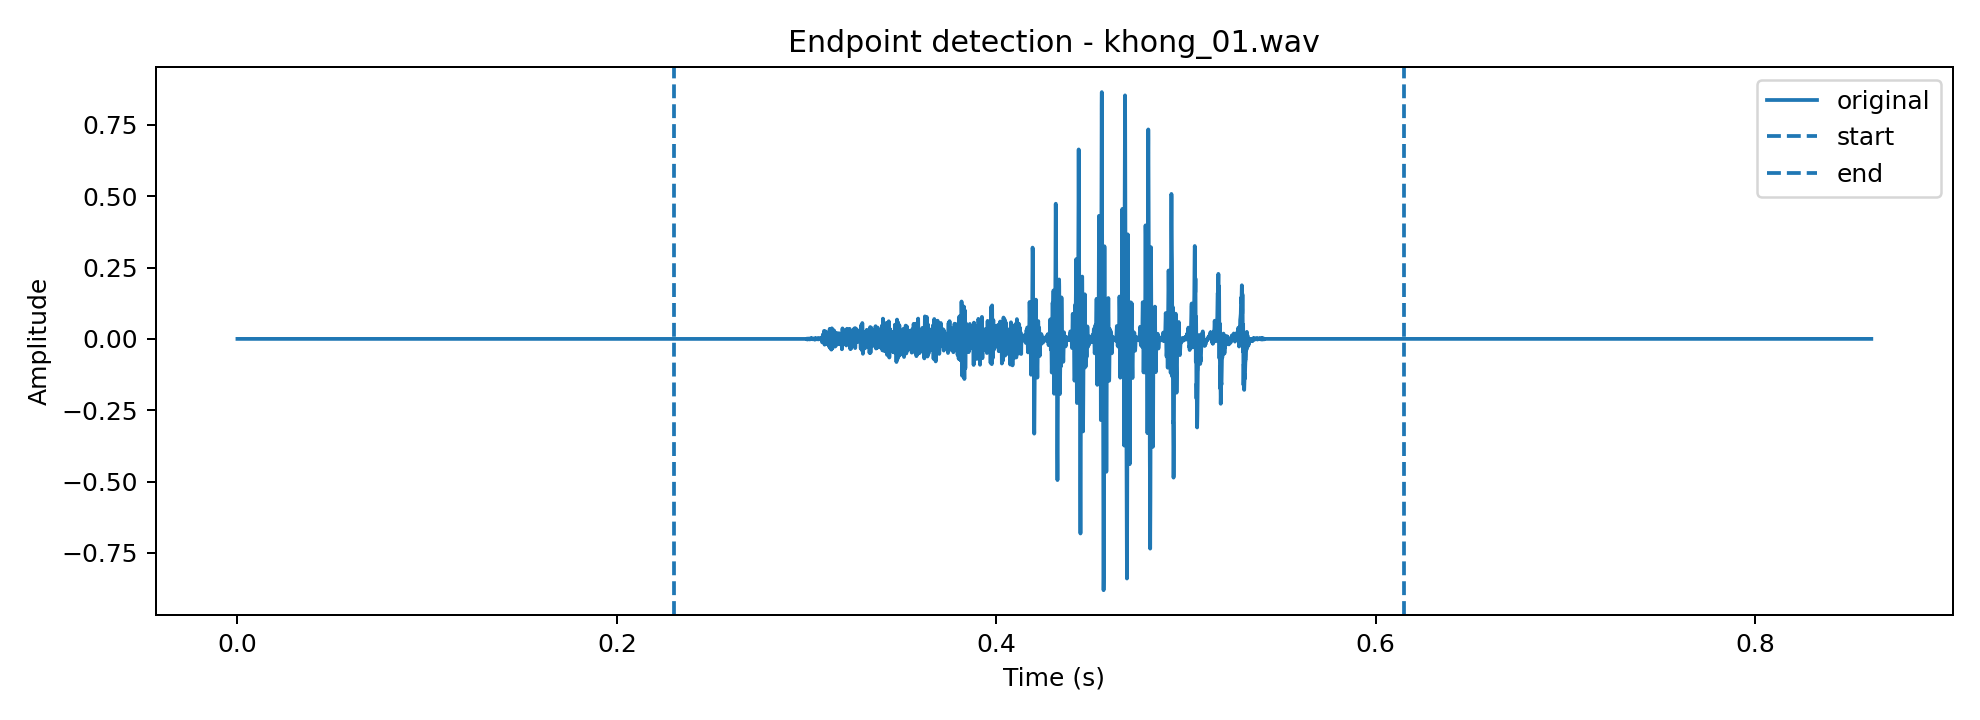

In [ ]:
ep=pd.read_csv(ROOT/'endpoint_results.csv')
display(ep.head(10))
print('Mean duration before:',ep.before_s.mean(),'after:',ep.after_s.mean())
display(Image(filename=str(ROOT/'figures'/'endpoint_detection.png')))

### Autocorrelation/pitch minh họa

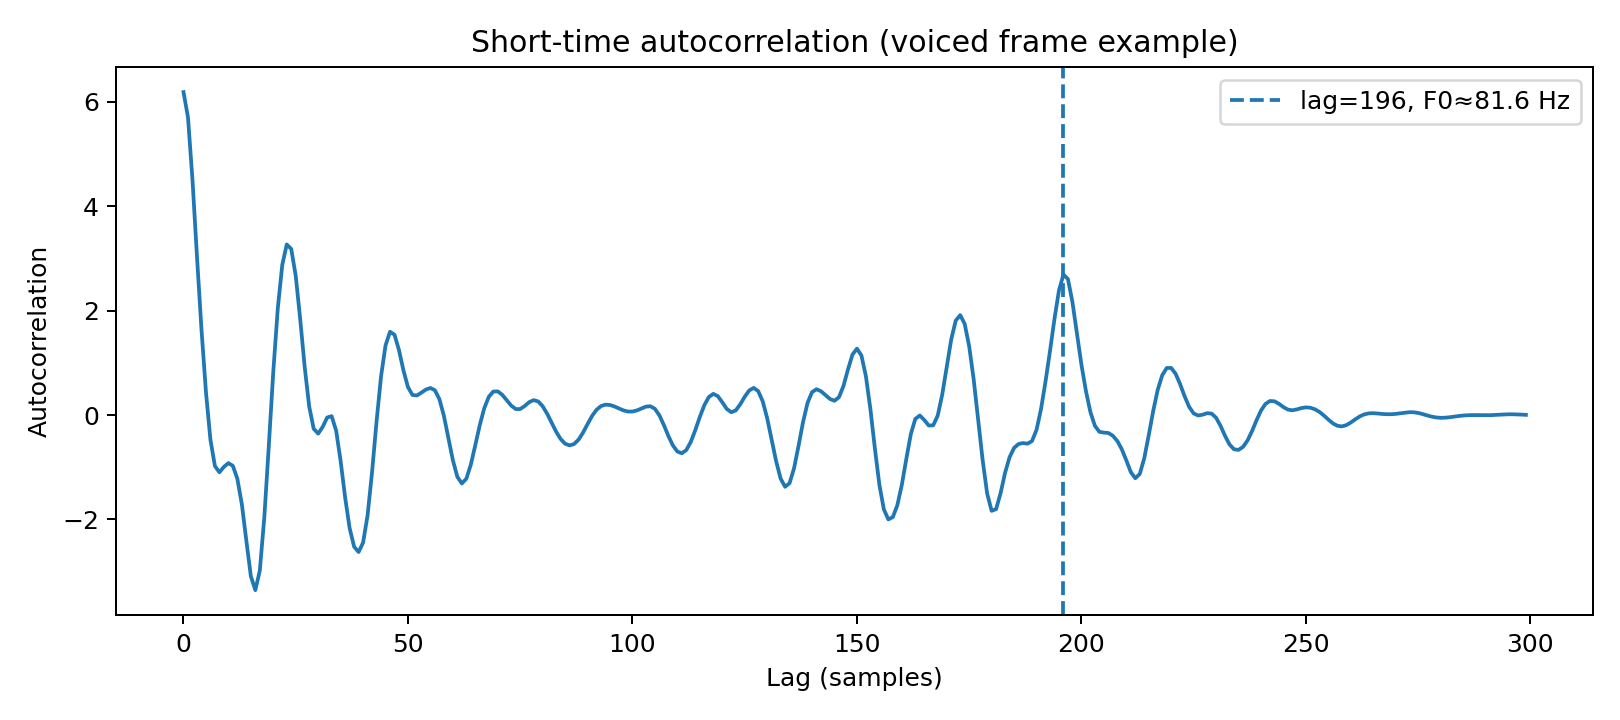

lag= 196 F0≈ 81.63265306122449 Hz


In [ ]:
display(Image(filename=str(ROOT/'figures'/'autocorrelation_pitch.png')))
ytrim,_,_=endpoint_detect(load_audio(DATA/'khong'/'khong_01.wav'))
ac,lag,f0=autocorrelation_pitch(ytrim)
print('lag=',lag,'F0≈',f0,'Hz')

## D. MFCC

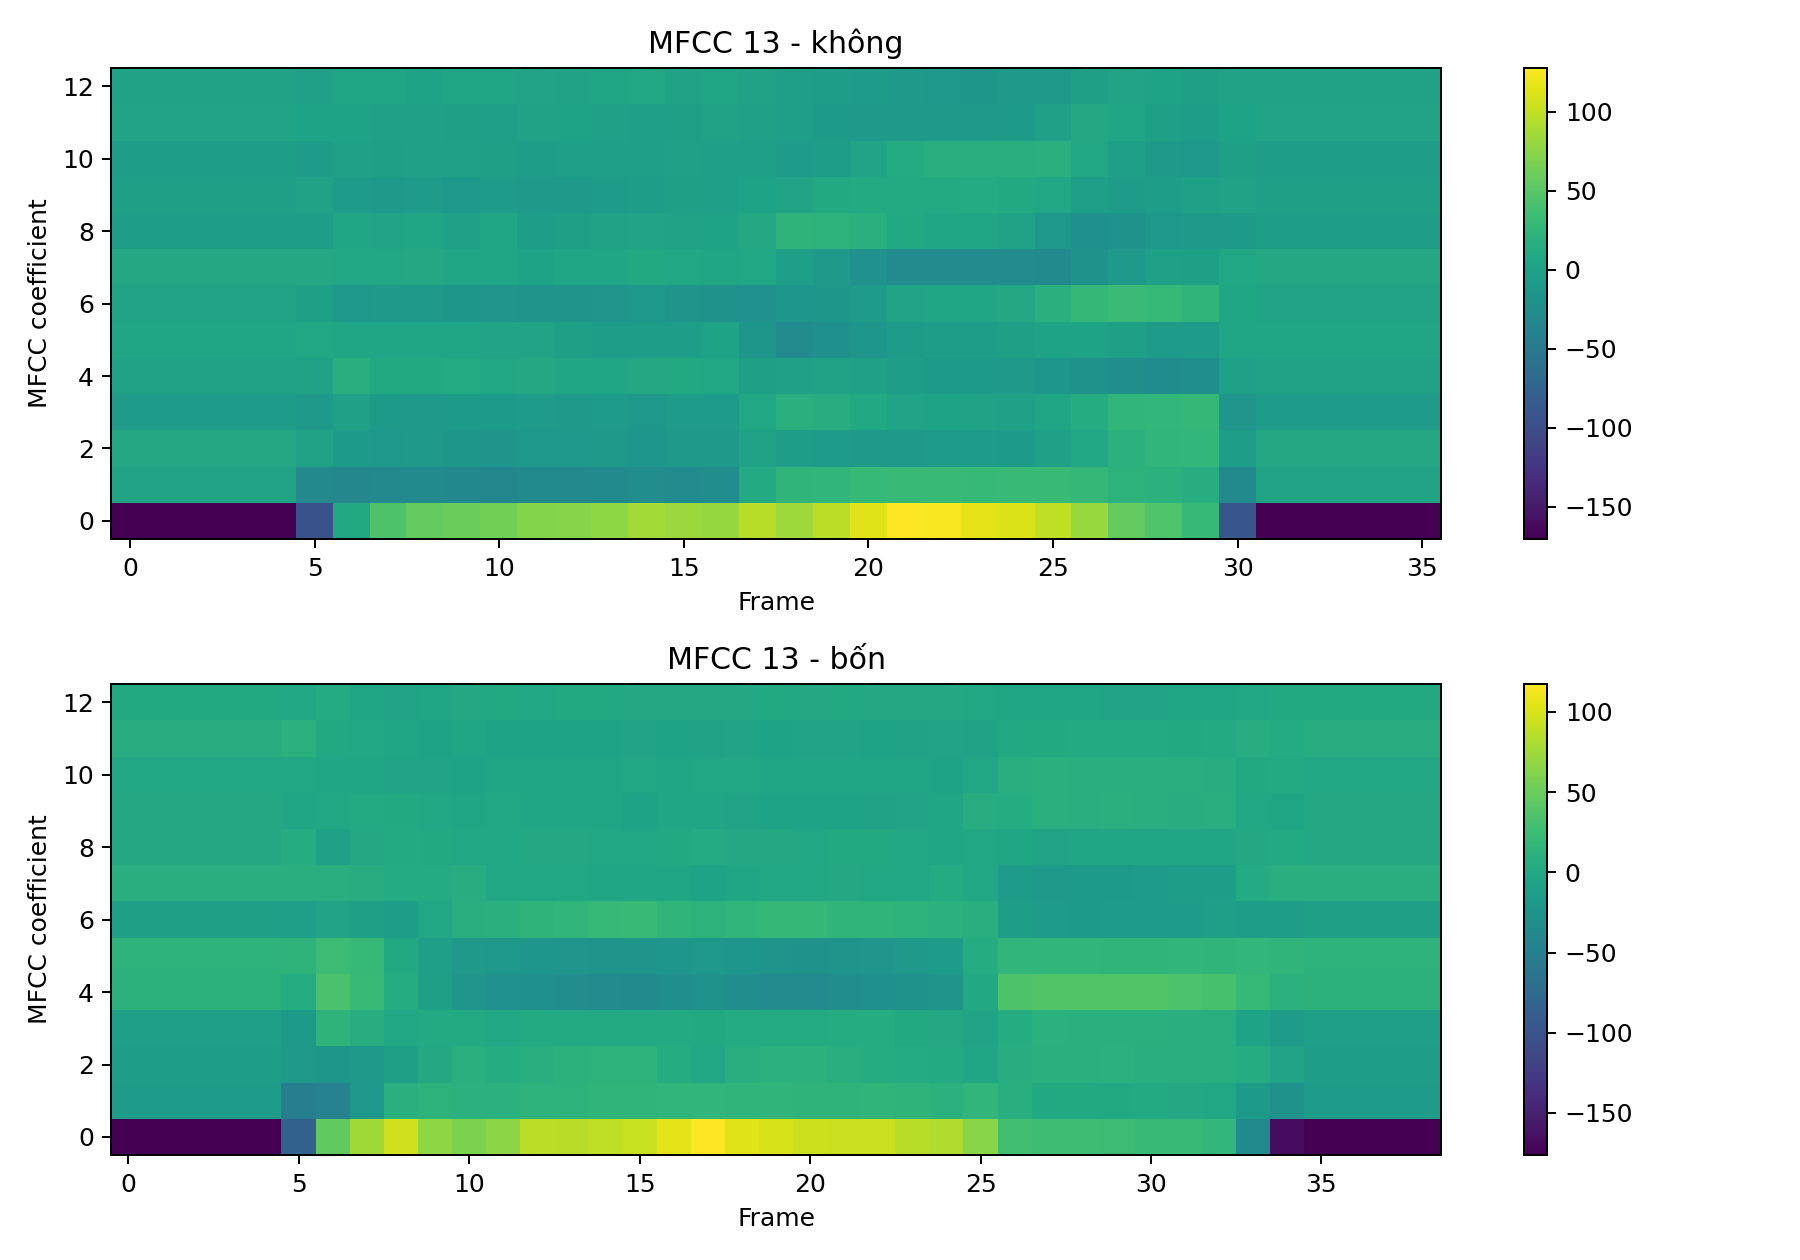

khong (36, 13)
bon (39, 13)


In [ ]:
display(Image(filename=str(ROOT/'figures'/'mfcc_two_words.png')))
for lab in ['khong','bon']:
    y,_,_=endpoint_detect(load_audio(DATA/lab/f'{lab}_01.wav'))
    M=mfcc_feature(y)
    print(lab, M.shape)

## E. DTW tự cài

DTW_norm cùng từ= 15.867425464448475
DTW_norm khác từ= 46.628553118024556


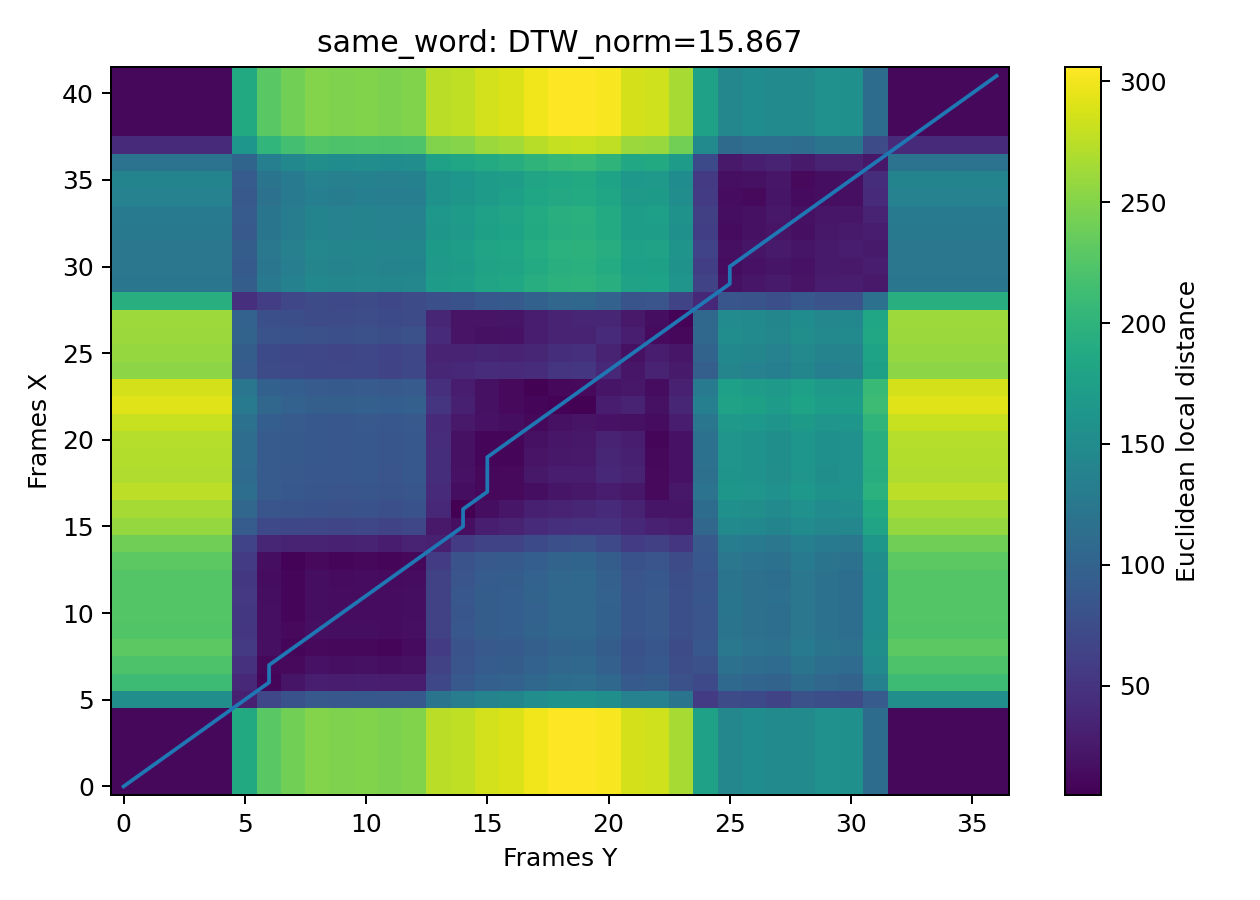

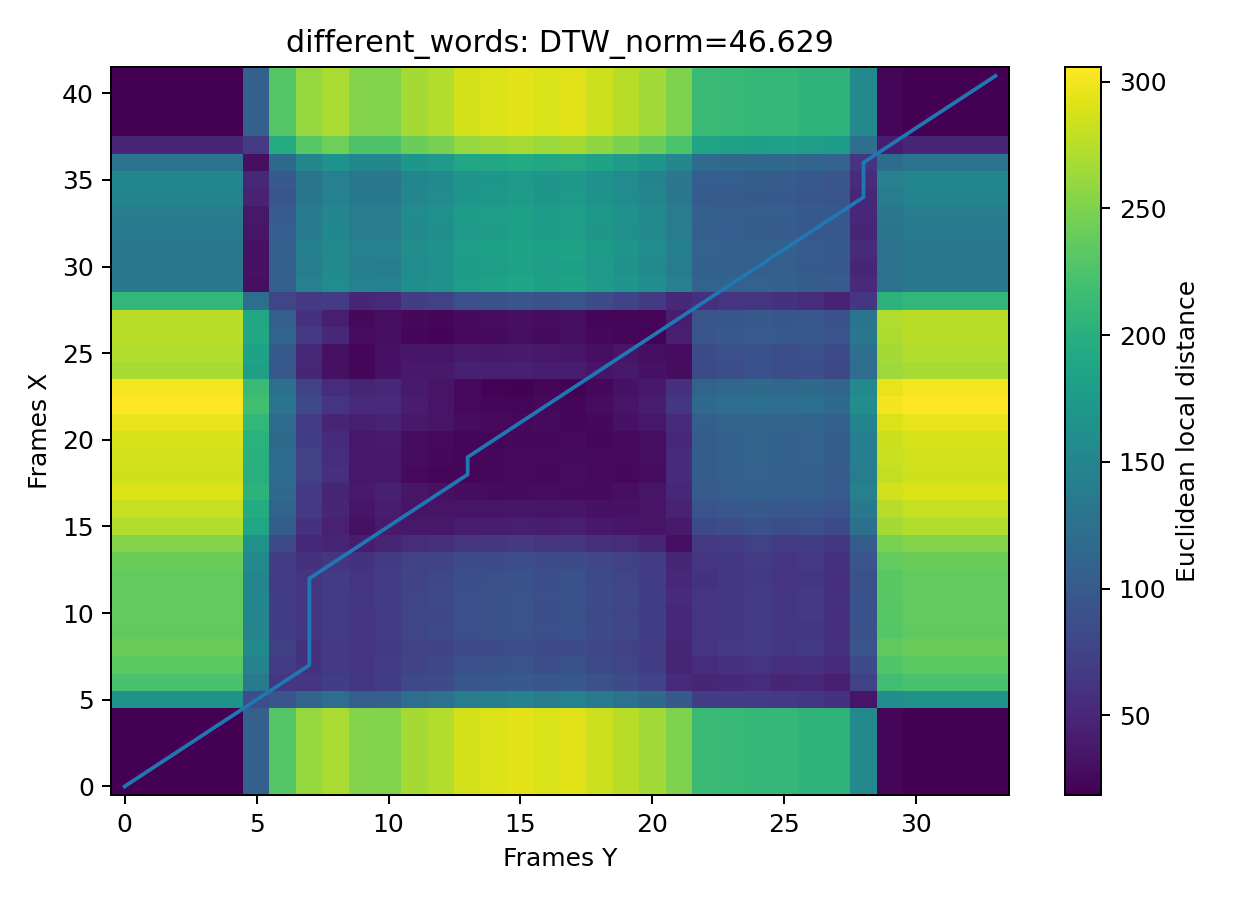

In [ ]:
X=extract(DATA/'mot'/'mot_01.wav'); Y=extract(DATA/'mot'/'mot_04.wav')
c_same,path,_,_=dtw_distance(X,Y)
A=extract(DATA/'bon'/'bon_04.wav'); c_diff,path2,_,_=dtw_distance(X,A)
print('DTW_norm cùng từ=',c_same)
print('DTW_norm khác từ=',c_diff)
display(Image(filename=str(ROOT/'figures'/'dtw_same_word.png')))
display(Image(filename=str(ROOT/'figures'/'dtw_different_words.png')))

## F. Bộ nhận dạng nearest-template

In [ ]:
acc,cm,results,templates=evaluate(DATA,trim=True,add_delta=False)
display(results)
print('Accuracy=',acc)

,file,true_label,pred_label,top1_label,top1_score,top2_label,top2_score,top3_label,top3_score
0,khong_04.wav,khong,khong,khong,7.730069,ba,47.340268,hai,50.490823
1,khong_05.wav,khong,khong,khong,7.992713,ba,45.160953,hai,47.243228
2,mot_04.wav,mot,mot,mot,13.225581,ba,47.502014,bon,47.561763
3,mot_05.wav,mot,mot,mot,11.007381,bon,46.765183,ba,46.879266
4,hai_04.wav,hai,hai,hai,11.147986,khong,45.349205,ba,47.867954
5,hai_05.wav,hai,hai,hai,10.001980,ba,49.185484,khong,49.356578
6,ba_04.wav,ba,ba,ba,7.443344,bon,44.729392,khong,45.726091
7,ba_05.wav,ba,ba,ba,9.644515,bon,46.949144,khong,48.822584
8,bon_04.wav,bon,bon,bon,9.177254,ba,44.477958,mot,45.022149
9,bon_05.wav,bon,bon,bon,11.262491,ba,41.497512,mot,47.642788


Accuracy= 1.0


## G. Đánh giá và thí nghiệm bắt buộc

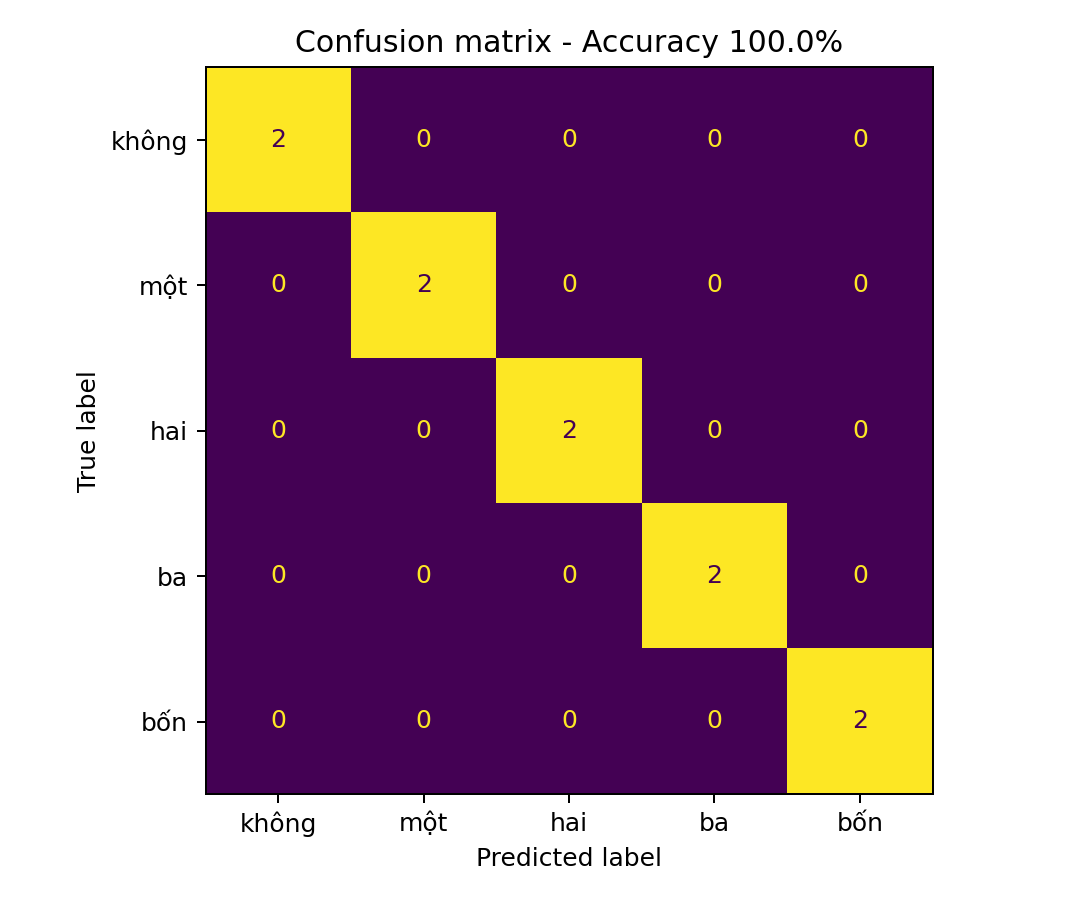

,experiment,endpoint_detection,mfcc_delta,accuracy
0,Baseline,True,False,1.0
1,E1_no_endpoint,False,False,1.0
2,E2_MFCC_delta,True,True,1.0


In [ ]:
display(Image(filename=str(ROOT/'figures'/'confusion_matrix.png')))
exp=pd.read_csv(ROOT/'experiment_results.csv')
display(exp)

## Kiểm tra bắt buộc DTW với chuỗi giống hệt

In [ ]:
X=extract(DATA/'hai'/'hai_01.wav')
c,_,_,_=dtw_distance(X,X)
print('DTW_norm(X,X)=',c)
assert c < 1e-6

DTW_norm(X,X)= 0.0


## Trả lời câu hỏi báo cáo
Phần trả lời chi tiết 9 câu nằm trong `Lab2_Report.md`/`Lab2_Report.pdf`. Tóm tắt: waveform không phù hợp để so trực tiếp khi tốc độ nói khác nhau; Energy + ZCR hỗ trợ endpoint; Mel mô phỏng thính giác; log nén dynamic range; DCT tạo cepstral coefficients; DTW ngang/dọc/chéo mô hình hóa co/giãn thời gian; chuẩn hóa path length giúp so sánh công bằng; MFCC biến thiên do người nói/kênh/tốc độ/nhiễu; DTW hạn chế cross-speaker và Chương 3 chuyển sang mô hình hóa thống kê như HMM.

## Kết luận
Pipeline đã chạy từ đầu đến cuối. Khi thay dataset bằng bản ghi cá nhân, hãy **Run All** lại notebook để cập nhật results, confusion matrix và nhận xét.